In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

df = pd.read_csv(
 r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_encoded_day13.csv"
)

In [3]:
# Separate Features & Target
X = df.drop(
    columns=["Churn"]
)

y = df["Churn"]

In [4]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
#Verify Split next 4 steps
X_train.shape

(5634, 45)

In [6]:
X_test.shape

(1409, 45)

In [7]:
y_train.value_counts(normalize=True)

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [ ]:
y_test.value_counts(normalize=True)

Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [ ]:
#create xgboost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [10]:
xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [11]:
#predictions
y_pred = xgb_model.predict(
    X_test
)

In [12]:
#accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

accuracy

0.7899219304471257

In [13]:
precision = precision_score(
    y_test,
    y_pred
)

precision

0.6274509803921569

In [ ]:
recall = recall_score(
    y_test,
    y_pred
)

recall


0.5133689839572193

In [15]:
f1 = f1_score(
    y_test,
    y_pred
)

f1

0.5647058823529412

In [16]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[921, 114],
       [182, 192]])

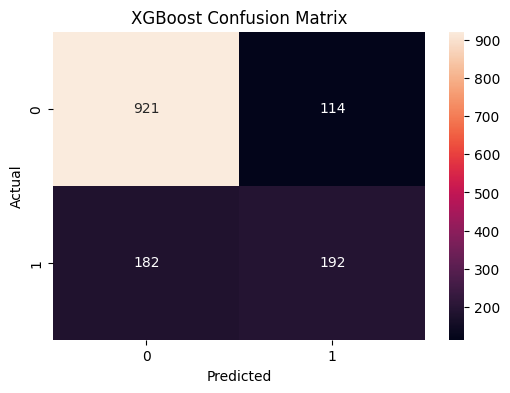

In [18]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [19]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

In [20]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
8,ContractSecurityScore,0.206969
31,Contract_Two year,0.192381
16,InternetService_Fiber optic,0.149948
17,InternetService_No,0.050831
18,OnlineSecurity_No internet service,0.042049
1,tenure,0.015515
13,PhoneService_Yes,0.015177
34,PaymentMethod_Electronic check,0.015085
27,StreamingTV_Yes,0.015011
29,StreamingMovies_Yes,0.014972


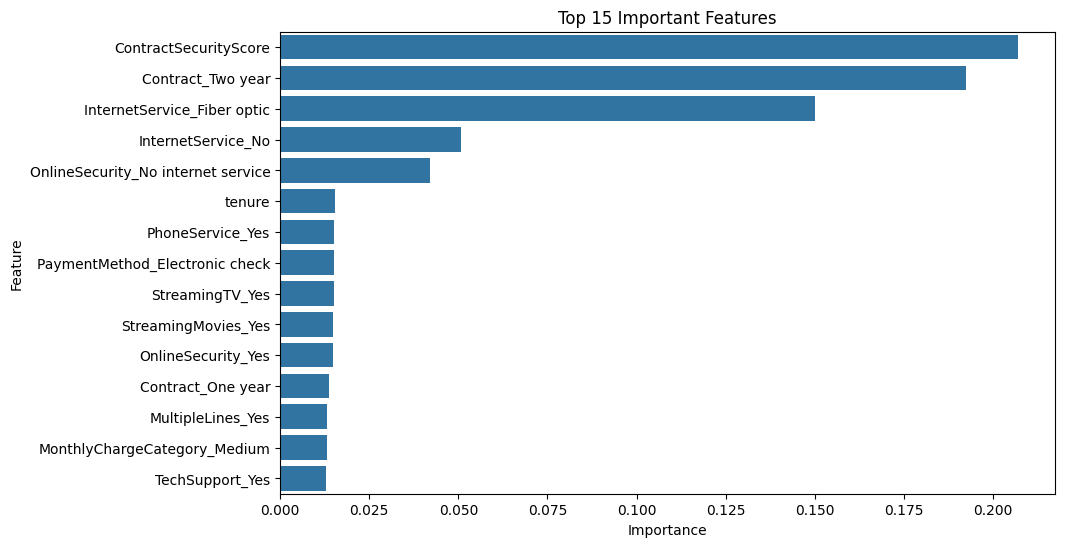

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

In [22]:
importance_df.to_csv(
    "../../models/artifacts/xgboost_feature_importance.csv",
    index=False
)

In [24]:
import pandas as pd
df.to_csv("../../data/processed/telco_churn_xgboost.csv", index=False)